## Import libraries

In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## Load the data

In [31]:
df = pd.read_csv("Downloads/UNSW_NB15_training-set.csv/UNSW_NB15_training-set.csv")
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [34]:
df.info

<bound method DataFrame.info of           id       dur proto service state  spkts  dpkts  sbytes  dbytes  \
0          1  0.000011   udp       -   INT      2      0     496       0   
1          2  0.000008   udp       -   INT      2      0    1762       0   
2          3  0.000005   udp       -   INT      2      0    1068       0   
3          4  0.000006   udp       -   INT      2      0     900       0   
4          5  0.000010   udp       -   INT      2      0    2126       0   
...      ...       ...   ...     ...   ...    ...    ...     ...     ...   
82327  82328  0.000005   udp       -   INT      2      0     104       0   
82328  82329  1.106101   tcp       -   FIN     20      8   18062     354   
82329  82330  0.000000   arp       -   INT      1      0      46       0   
82330  82331  0.000000   arp       -   INT      1      0      46       0   
82331  82332  0.000009   udp       -   INT      2      0     104       0   

                rate  ...  ct_dst_sport_ltm  ct_dst_src

## Basic cleaning

In [35]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [36]:
# Check missing values
df.isnull().sum().sort_values(ascending=False).head(20)

id                   0
dwin                 0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports      0
dtype: int64

In [38]:
# Replace infinity values if present
df = df.replace([np.inf, -np.inf], np.nan)
# Drop rows with missing values for this baseline version
df = df.dropna()
df.shape

(82332, 45)

## Identify target variable

In [39]:
df["label"].value_counts()

label
1    45332
0    37000
Name: count, dtype: int64

The label column represents whether traffic is benign or malicious.  
0 = benign traffic  
1 = malicious traffic

## EDA: benign vs. malicious traffic

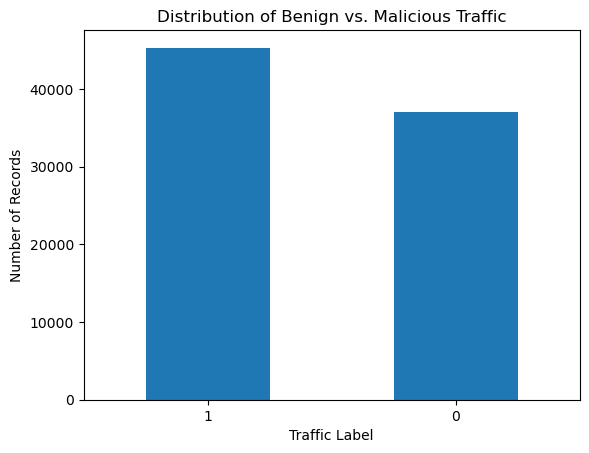

In [13]:
df["label"].value_counts().plot(kind="bar")
plt.title("Distribution of Benign vs. Malicious Traffic")
plt.xlabel("Traffic Label")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

## EDA: attack categories

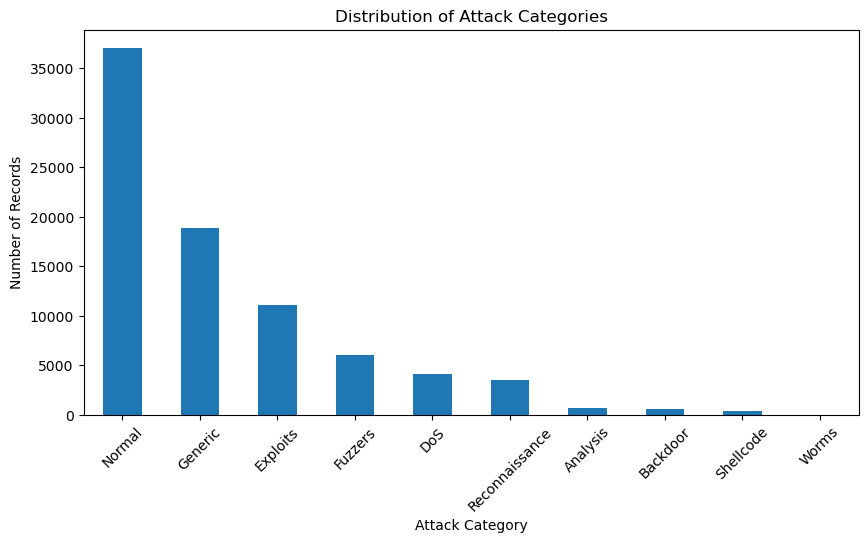

In [14]:
if "attack_cat" in df.columns:
    df["attack_cat"].value_counts().plot(kind="bar", figsize=(10,5))
    plt.title("Distribution of Attack Categories")
    plt.xlabel("Attack Category")
    plt.ylabel("Number of Records")
    plt.xticks(rotation=45)
    plt.show()

## EDA: summary statistics

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,82332.0,4.116650e+04,2.376735e+04,1.0,20583.750000,4.116650e+04,6.174925e+04,8.233200e+04
dur,82332.0,1.006756e+00,4.710444e+00,0.0,0.000008,1.413800e-02,7.193603e-01,5.999999e+01
spkts,82332.0,1.866647e+01,1.339164e+02,1.0,2.000000,6.000000e+00,1.200000e+01,1.064600e+04
dpkts,82332.0,1.754594e+01,1.155741e+02,0.0,0.000000,2.000000e+00,1.000000e+01,1.101800e+04
sbytes,82332.0,7.993908e+03,1.716423e+05,24.0,114.000000,5.340000e+02,1.280000e+03,1.435577e+07
dbytes,82332.0,1.323379e+04,1.514715e+05,0.0,0.000000,1.780000e+02,9.560000e+02,1.465753e+07
rate,82332.0,8.241089e+04,1.486204e+05,0.0,28.606114,2.650177e+03,1.111111e+05,1.000000e+06
sttl,82332.0,1.809677e+02,1.015134e+02,0.0,62.000000,2.540000e+02,2.540000e+02,2.550000e+02
dttl,82332.0,9.571300e+01,1.166677e+02,0.0,0.000000,2.900000e+01,2.520000e+02,2.530000e+02
sload,82332.0,6.454902e+07,1.798618e+08,0.0,11202.466797,5.770032e+05,6.514286e+07,5.268000e+09


## EDA: compare numeric features by label

In [16]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Remove target column from feature list
if "label" in numeric_cols:
    numeric_cols.remove("label")

numeric_cols[:10]

['id',
 'dur',
 'spkts',
 'dpkts',
 'sbytes',
 'dbytes',
 'rate',
 'sttl',
 'dttl',
 'sload']

In [17]:
df.groupby("label")[numeric_cols].mean().T.head(15)

label,0,1
id,5.136036e+04,3.284627e+04
dur,1.012727e+00,1.001882e+00
spkts,2.277697e+01,1.531148e+01
dpkts,2.541532e+01,1.112294e+01
sbytes,4.072377e+03,1.119466e+04
dbytes,1.870493e+04,8.768235e+03
rate,2.834999e+04,1.265354e+05
sttl,1.243190e+02,2.272044e+02
dttl,1.084447e+02,8.532138e+01
sload,3.975339e+07,8.478722e+07


## EDA: histograms of key features

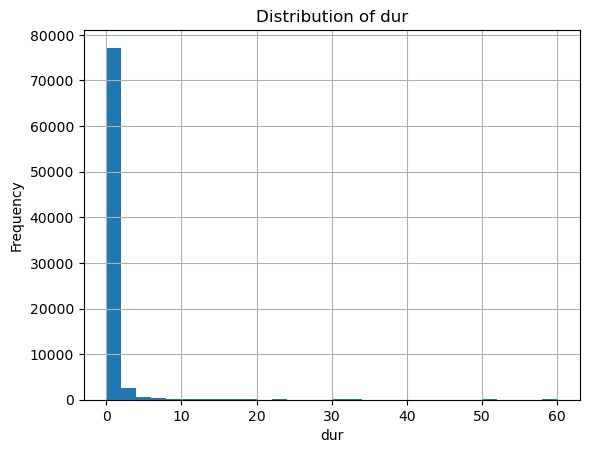

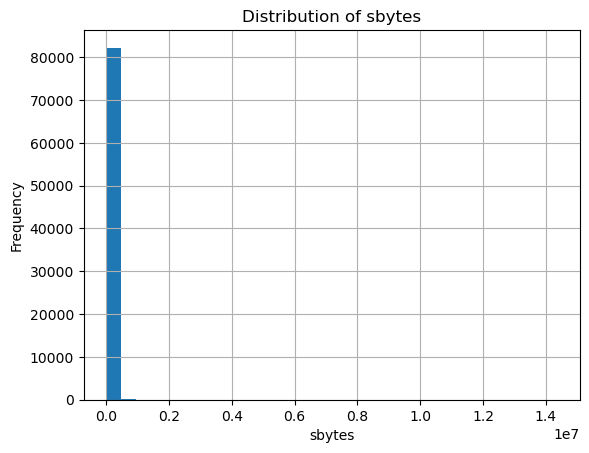

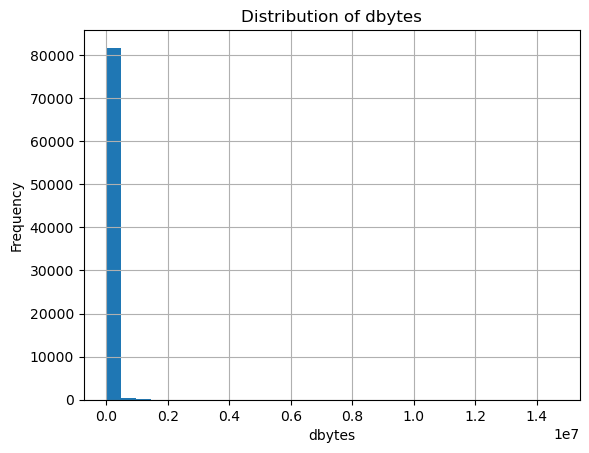

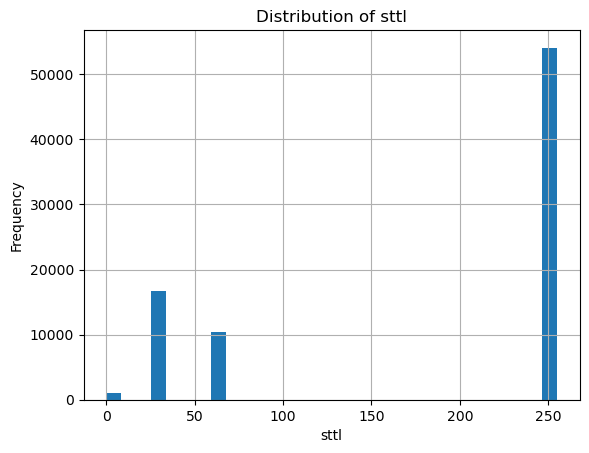

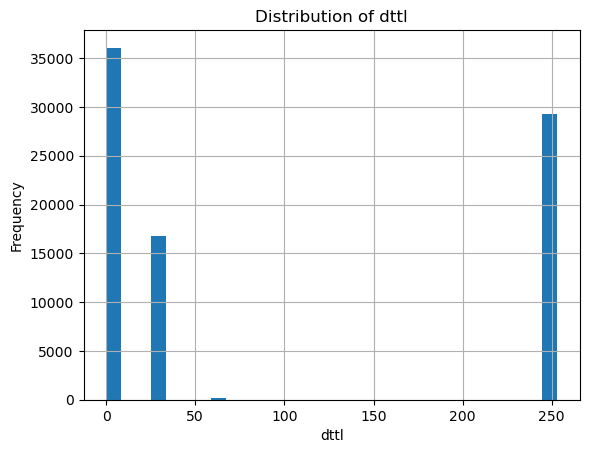

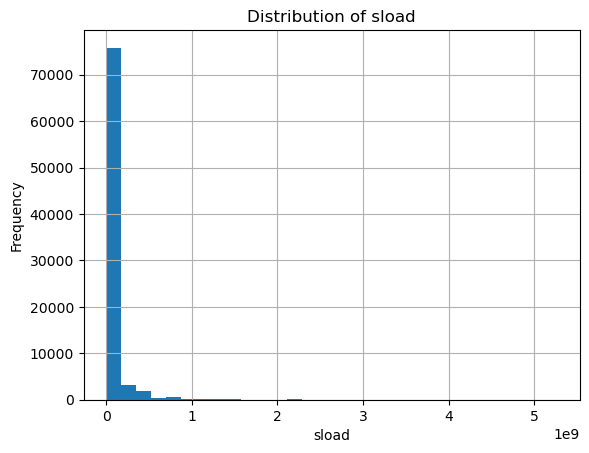

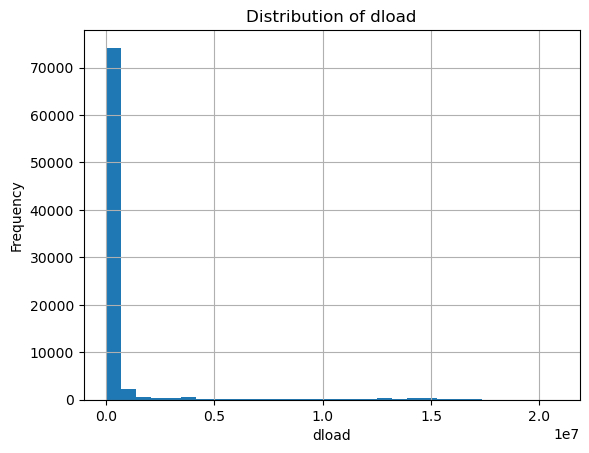

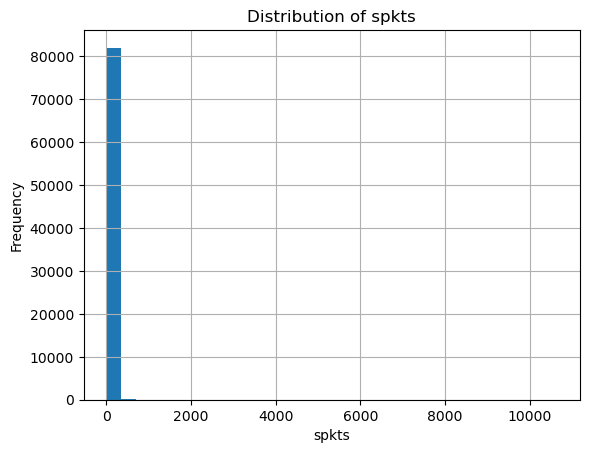

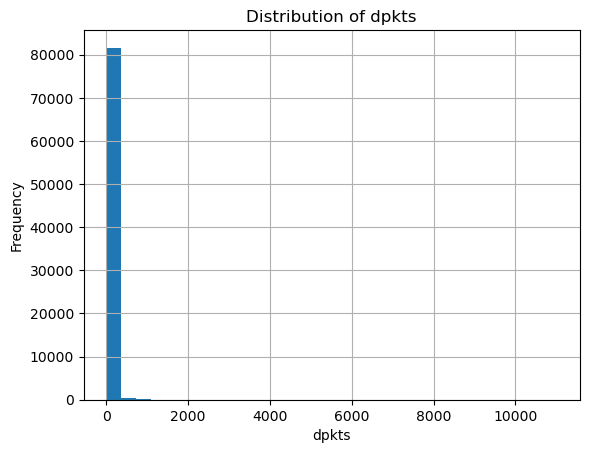

In [18]:
possible_features = ["dur", "sbytes", "dbytes", "sttl", "dttl", "sload", "dload", "spkts", "dpkts"]

for col in possible_features:
    if col in df.columns:
        df[col].hist(bins=30)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

## EDA: correlation with target

In [20]:
corr = df.select_dtypes(include=["int64", "float64"]).corr(numeric_only=True)

label_corr = corr["label"].sort_values(ascending=False)

label_corr.head(15)

label               1.000000
sttl                0.504159
ct_dst_sport_ltm    0.393668
ct_src_dport_ltm    0.341513
rate                0.328629
ct_state_ttl        0.318517
ct_srv_dst          0.292931
ct_srv_src          0.290195
ct_dst_src_ltm      0.279989
ct_src_ltm          0.276494
ct_dst_ltm          0.257995
sload               0.124548
sbytes              0.020641
sloss               0.006360
dur                -0.001145
Name: label, dtype: float64

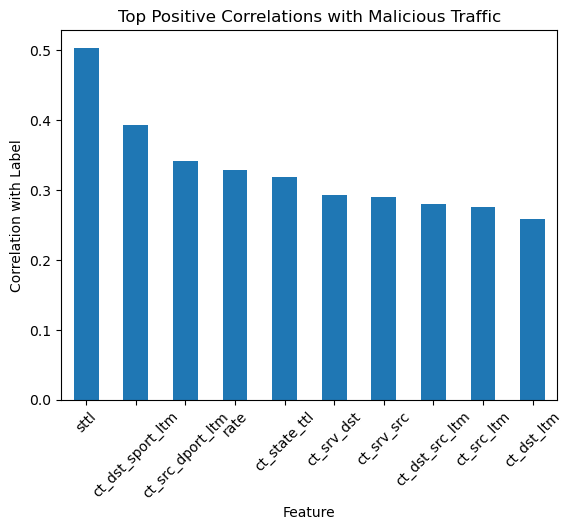

In [21]:
label_corr.drop("label").head(10).plot(kind="bar")
plt.title("Top Positive Correlations with Malicious Traffic")
plt.xlabel("Feature")
plt.ylabel("Correlation with Label")
plt.xticks(rotation=45)
plt.show()

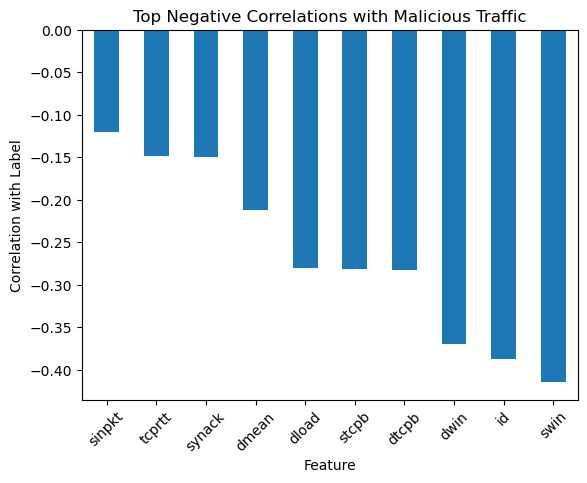

In [22]:
label_corr.drop("label").tail(10).plot(kind="bar")
plt.title("Top Negative Correlations with Malicious Traffic")
plt.xlabel("Feature")
plt.ylabel("Correlation with Label")
plt.xticks(rotation=45)
plt.show()

## Prepare features and target

In [23]:
# Drop columns that leak the answer or are not useful for prediction
drop_cols = ["label"]

# attack_cat tells the specific attack type, so drop it for binary prediction
if "attack_cat" in df.columns:
    drop_cols.append("attack_cat")

X = df.drop(columns=drop_cols)
y = df["label"]

X.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,1,1,2,0,0,0,1,2,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,1,1,2,0,0,0,1,2,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,1,1,3,0,0,0,1,3,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,2,2,1,3,0,0,0,2,3,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,2,2,1,3,0,0,0,2,3,0


## Identify numeric and categorical columns

In [24]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", categorical_features)

Numeric features: 40
Categorical features: ['proto', 'service', 'state']


## Train/test split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

X_train.shape, X_test.shape

((65865, 43), (16467, 43))

## Build baseline Logistic Regression model

In [26]:
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

baseline_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Evaluate baseline model

In [27]:
y_pred = baseline_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9545758183032732
Precision: 0.9546398513498743
Recall: 0.9632734090658431
F1 Score: 0.9589371980676329


In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.95      7400
           1       0.95      0.96      0.96      9067

    accuracy                           0.95     16467
   macro avg       0.95      0.95      0.95     16467
weighted avg       0.95      0.95      0.95     16467



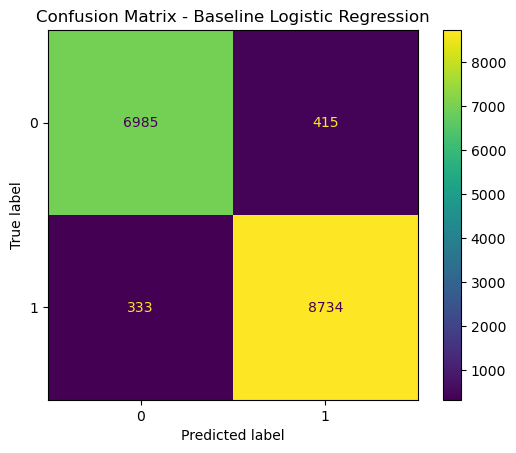

In [29]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Baseline Logistic Regression")
plt.show()

## Initial Results

The exploratory data analysis showed that malicious and benign traffic are not evenly distributed, which is important because class imbalance can affect model performance. Several network traffic features appear to differ between benign and malicious activity, including duration, packet counts, byte counts, and connection-related variables.

The baseline Logistic Regression model provides an initial benchmark for performance. For cybersecurity use cases, recall is especially important because a false negative means malicious traffic was missed. Precision is also important because too many false positives can overwhelm security analysts.

This baseline model will be compared against more advanced models in the next module, such as Decision Tree, Random Forest, KNN, and SVM.